# Multivariate Log-Normal Distribution

`MultivariateLogNormal(mean, cov)` is the multivariate generalization of the log-normal: the elementwise exponential of a `MultivariateNormal`. If `Y` is multivariate normal, then `X = exp(Y)` (component by component) is multivariate log-normal.

In [19]:
from symbulate import *

## Draw a value

Each draw is a vector of positive values.

In [20]:
MultivariateLogNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]]).draw()

(0.03539235160954836, 0.1843573919324775)

## Simulate

Every simulated value is a vector of positive, correlated values.

In [21]:
MultivariateLogNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]]).sim(1000)

0,"(0.6235732774674139, 0.2355160342104823)"
1,"(1.1099461268881727, 0.7625523857689042)"
2,"(1.890813592979543, 0.8399317673174963)"
3,"(0.8352333204045653, 0.3654937055553667)"
4,"(2.1965536122451987, 4.15727688601141)"
5,"(1.186227213545271, 1.9447630083344414)"
6,"(1.2344789976075163, 0.8296119555078632)"
7,"(0.5981109470286138, 1.5359283511982367)"
8,"(0.760246920364671, 0.825328729070041)"
...,...
999,"(1.6558289918123497, 1.0071322013940143)"


## Mean, variance, and standard deviation

Each component's mean is `exp(mean_i + cov_ii / 2)`.

In [22]:
X = MultivariateLogNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]])
X.mean(), X.var(), X.sd()

((1.6487212707001282, 1.6487212707001282),
 (4.670774270471604, 4.670774270471604),
 (2.1611974158950877, 2.1611974158950877))

## Covariance matrix

`cov()` applies the standard log-normal transform to the underlying covariance: entry `(i, j)` is `exp(mean_i + mean_j + (cov_ii + cov_jj)/2) * (exp(cov_ij) - 1)`. A positive underlying correlation stays positive here.

In [23]:
X.cov()

array([[4.67077427, 1.76340724],
       [1.76340724, 4.67077427]])

## Correlation matrix

`corr()` rescales the covariance into correlations between -1 and 1.

In [24]:
X.corr()

array([[1.        , 0.37754067],
       [0.37754067, 1.        ]])

## Evaluate the pdf at a point

The density is defined on the positive orthant (every coordinate must be greater than 0).

In [25]:
MultivariateLogNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]]).pdf([1, 1])

np.float64(0.1837762984739307)

## Relationship: each component is a univariate LogNormal

Component `i` is marginally `LogNormal(mu=mean_i, sigma=sqrt(cov_ii))`. Here the first component of `MultivariateLogNormal([0.3, 1.0], [[0.25, 0], [0, 0.5]])` is `LogNormal(mu=0.3, sigma=0.5)` (since `sqrt(0.25) = 0.5`).

In [ ]:
A, B = RV(MultivariateLogNormal(mean=[0.3, 1.0], cov=[[0.25, 0], [0, 0.5]]))
A.sim(10000).plot(type="density")
LogNormal(mu=0.3, sigma=0.5).plot()

## Relationship: the log of a draw is Normal

By construction the multivariate log-normal is `exp` of a multivariate normal, so taking logs runs the definition backwards: each `log(X_i)` is the underlying `Normal(mean_i, sqrt(cov_ii))`. Here `log` of the first component of `MultivariateLogNormal([2, -1], [[1, 0], [0, 4]])` is `Normal(2, sd=1)`.

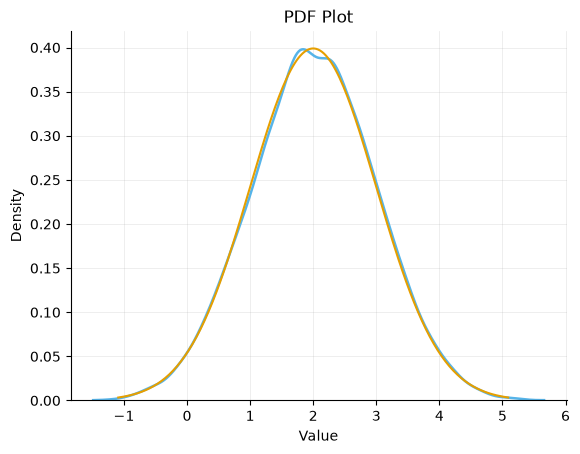

In [ ]:
C, D = RV(MultivariateLogNormal(mean=[2, -1], cov=[[1, 0], [0, 4]]))
C.apply(log).sim(10000).plot(type="density")
Normal(mean=2, sd=1).plot()